# 2.5
# Методы Ньютона

### Упражнение №1

In [1]:
from numpy import *
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from math import *

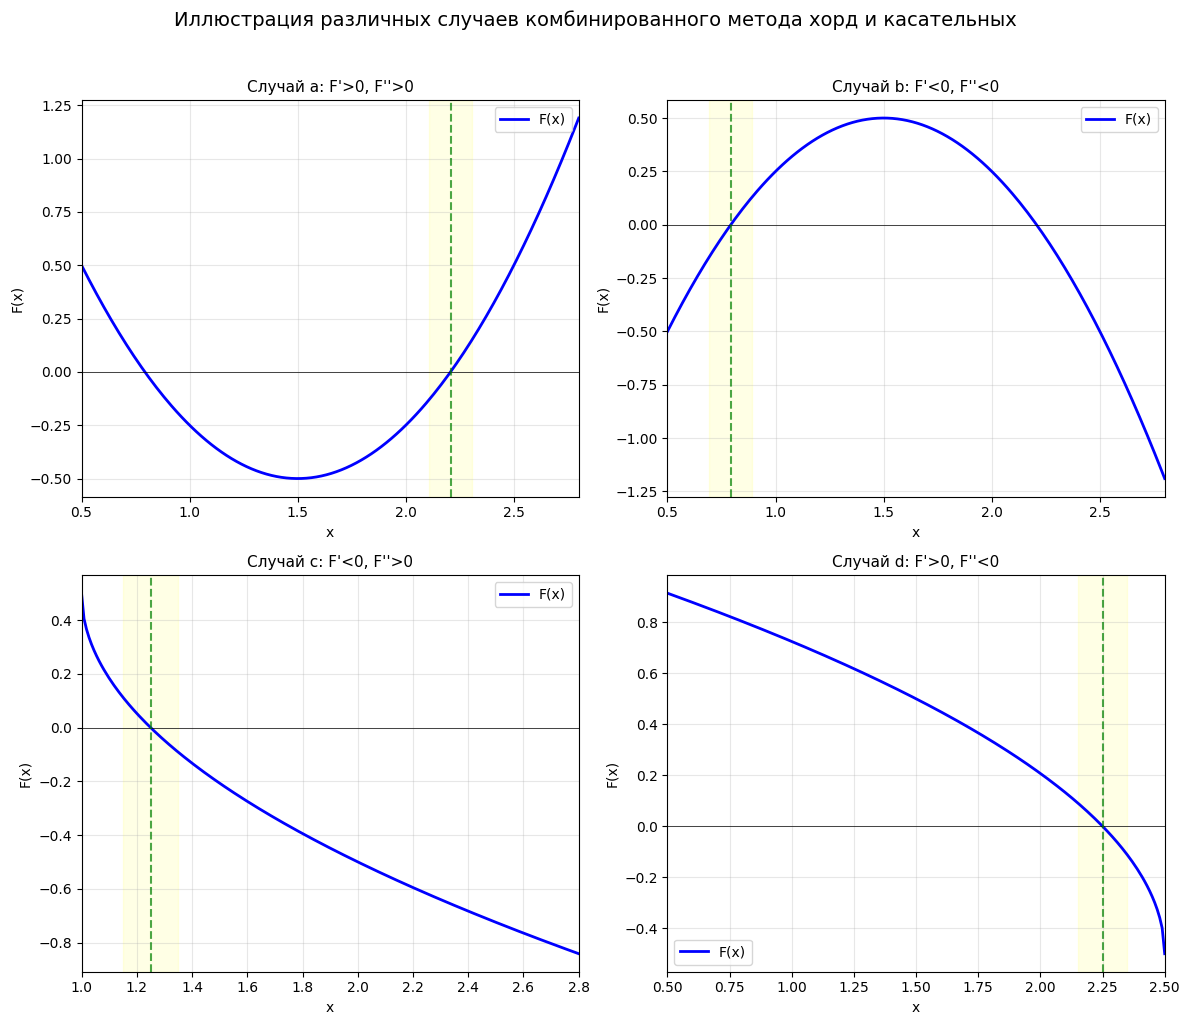


ДЕТАЛЬНЫЙ АНАЛИЗ ПРОИЗВОДНЫХ:

Случай a: F'>0, F''>0
  Корень: x* = 2.207107
  F'(1.65) = 0.3000 (положительная)
  F''(1.65) = 2.0000 (положительная)
  Знак F·F'': 1.0

Случай b: F'<0, F''<0
  Корень: x* = 0.792893
  F'(1.65) = -0.3000 (отрицательная)
  F''(1.65) = -2.0000 (отрицательная)
  Знак F·F'': 1.0

Случай c: F'<0, F''>0
  Корень: x* = 1.250000
  F'(1.90) = -0.5270 (отрицательная)
  F''(1.90) = 0.2928 (положительная)
  Знак F·F'': 1.0

Случай d: F'>0, F''<0
  Корень: x* = 2.250000
  F'(1.50) = -0.5000 (отрицательная)
  F''(1.50) = -0.2500 (отрицательная)
  Знак F·F'': -1.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Вариант 2: с защитой от передачи массива
def safe_sqrt(x):
    """Безопасная версия sqrt, работающая с массивами"""
    if hasattr(x, '__len__'):
        return np.sqrt(x)
    else:
        from math import sqrt
        return sqrt(x)

# 4 разных случая
funcs = [
    lambda x: (x-1.5)**2 - 0.5,
    lambda x: -(x-1.5)**2 + 0.5,
    lambda x: -safe_sqrt(x-1) + 0.5,
    lambda x: safe_sqrt(2.5-x) - 0.5
]

titles = ["F'>0, F''>0", "F'<0, F''<0", "F'<0, F''>0", "F'>0, F''<0"]
roots = [1.5+np.sqrt(0.5), 1.5-np.sqrt(0.5), 1.25, 2.25]
x_ranges = [(0.5, 2.8), (0.5, 2.8), (1.0, 2.8), (0.5, 2.5)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (f, title, root, x_range) in enumerate(zip(funcs, titles, roots, x_ranges)):
    x = np.linspace(x_range[0], x_range[1], 200)
    y = f(x)
    
    axes[i].plot(x, y, 'b-', linewidth=2, label='F(x)')
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axvline(root, color='g', linestyle='--', alpha=0.7, linewidth=1.5)
    axes[i].set_title(f'Случай {chr(97+i)}: {title}', fontsize=11)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('F(x)')
    axes[i].set_xlim(x_range[0], x_range[1])
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='best')
    
    # Закрашиваем область вокруг корня
    axes[i].axvspan(root-0.1, root+0.1, alpha=0.1, color='yellow')

plt.suptitle('Иллюстрация различных случаев комбинированного метода хорд и касательных', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Вычисляем производные для каждого случая
print("\n" + "="*70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПРОИЗВОДНЫХ:")
print("="*70)

for i, (f, title, root, x_range) in enumerate(zip(funcs, titles, roots, x_ranges)):
    # Численное вычисление производных
    h = 1e-5
    x0 = (x_range[0] + x_range[1]) / 2
    Fp = (f(x0 + h) - f(x0 - h)) / (2*h)
    Fpp = (f(x0 + 2*h) - 2*f(x0) + f(x0 - 2*h)) / (4*h*h)
    
    print(f"\nСлучай {chr(97+i)}: {title}")
    print(f"  Корень: x* = {root:.6f}")
    print(f"  F'({x0:.2f}) = {Fp:.4f} {'(положительная)' if Fp > 0 else '(отрицательная)'}")
    print(f"  F''({x0:.2f}) = {Fpp:.4f} {'(положительная)' if Fpp > 0 else '(отрицательная)'}")
    print(f"  Знак F·F'': {np.sign(f(x_range[0]) * Fpp)}")

### Задание №2

In [4]:
import numpy as np
import pandas as pd

def combined_method_simple(a, b, eps=10 ** -6):
    # функция и производные
    F = lambda x: x**3 + 3 * x**2 - 24 * x + 1
    Fp = lambda x: 3 * x**2 + 6 * x - 24
    Fpp = lambda x: 6 * x + 6
    
    print("=" * 80)
    print("КОМБИНИРОВАННЫЙ МЕТОД (ХОРД + КАСАТЕЛЬНЫХ)")
    print("=" * 80)
    
    # проверка условия сходимости
    print(f"\nПроверка условия сходимости на отрезке [{a}, {b}]:")
    print(f"f({a}) = {F(a):.6f}, f({b}) = {F(b):.6f}")
    print(f"f'({a}) = {Fp(a):.2f}, f'({b}) = {Fp(b):.2f}")
    print(f"f''({a}) = {Fpp(a):.2f}, f''({b}) = {Fpp(b):.2f}")
    
    # выбор неподвижного конца
    if F(a) * Fpp(a) > 0:
        c, x_chord, x_tan = a, b, a
        print(f"\n✅ Касательная из левого конца: c = {c}")
        print(f"   Неподвижный конец: c = {c}")
        print(f"   Начальное приближение для хорд: {x_chord}")
        print(f"   Начальное приближение для касательных: {x_tan}")
    else:
        c, x_chord, x_tan = b, a, b
        print(f"\n✅ Касательная из правого конца: c = {c}")
        print(f"   Неподвижный конец: c = {c}")
        print(f"   Начальное приближение для хорд: {x_chord}")
        print(f"   Начальное приближение для касательных: {x_tan}")
    
    print("\n" + "-" * 80)
    
    # Список для хранения данных
    data = []
    
    for i in range(1, 20):
        # метод хорд
        x_chord_new = (c * F(x_chord) - x_chord * F(c)) / (F(x_chord) - F(c))
        
        # метод касательных
        x_tan_new = x_tan - F(x_tan) / Fp(x_tan)
        
        diff = abs(x_chord_new - x_tan_new)
        root_approx = (x_chord_new + x_tan_new) / 2
        f_root = F(root_approx)
        
        # Добавляем данные в список
        data.append({
            'Итерация': i,
            'x_chord': x_chord_new,
            'x_tan': x_tan_new,
            '|x_chord - x_tan|': diff,
            'F(x_средн)': f_root
        })
        
        if diff < eps:
            # Создаем DataFrame
            df = pd.DataFrame(data)
            
            # Настройки форматирования
            pd.set_option('display.max_rows', None)
            pd.set_option('display.width', None)
            pd.set_option('display.float_format', '{:.8f}'.format)
            
            # Выводим таблицу
            print(df.to_string(index=False))
            print("-" * 80)
            
            root = root_approx
            print(f"\n{'='*80}")
            print(f"РЕЗУЛЬТАТЫ РАСЧЕТА:")
            print(f"{'='*80}")
            print(f"✓ Сходимость достигнута на итерации {i}")
            print(f"✓ Корень уравнения: x = {root:.10f}")
            print(f"✓ Достигнутая точность: {diff:.2e} < {eps:.0e}")
            print(f"✓ Проверка: F({root:.10f}) = {F(root):.2e}")
            print(f"✓ Невязка: {abs(F(root)):.2e}")
            print(f"{'='*80}")
            return root
        
        x_chord, x_tan = x_chord_new, x_tan_new
    
    # Если достигнут максимум итераций
    df = pd.DataFrame(data)
    pd.set_option('display.float_format', '{:.8f}'.format)
    print(df.to_string(index=False))
    print("-" * 80)
    print(f"\n{'='*80}")
    print(f"⚠️ Достигнуто максимальное число итераций (19)")
    print(f"Последнее приближение: x = {root_approx:.10f}")
    print(f"Невязка: {abs(F(root_approx)):.2e}")
    print(f"{'='*80}")
    
    return (x_chord + x_tan) / 2

# Вызов функции
combined_method_simple(0, 1, 10 ** -6)

КОМБИНИРОВАННЫЙ МЕТОД (ХОРД + КАСАТЕЛЬНЫХ)

Проверка условия сходимости на отрезке [0, 1]:
f(0) = 1.000000, f(1) = -19.000000
f'(0) = -24.00, f'(1) = -15.00
f''(0) = 6.00, f''(1) = 12.00

✅ Касательная из левого конца: c = 0
   Неподвижный конец: c = 0
   Начальное приближение для хорд: 1
   Начальное приближение для касательных: 0

--------------------------------------------------------------------------------
 Итерация    x_chord      x_tan  |x_chord - x_tan|  F(x_средн)
        1 0.05000000 0.04166667         0.00833333 -0.09360163
        2 0.04193312 0.04188906         0.00004406 -0.00052288
        3 0.04188930 0.04188907         0.00000024 -0.00000283
--------------------------------------------------------------------------------

РЕЗУЛЬТАТЫ РАСЧЕТА:
✓ Сходимость достигнута на итерации 3
✓ Корень уравнения: x = 0.0418891852
✓ Достигнутая точность: 2.38e-07 < 1e-06
✓ Проверка: F(0.0418891852) = -2.83e-06
✓ Невязка: 2.83e-06


0.04188918518497596